<a href="https://colab.research.google.com/github/RahulKumar2340029/shap_v1/blob/main/shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap

In [2]:
!pip install scikit-learn

In [3]:
# Importing SHAP for model interpretation
import shap

# Importing scikit-learn for machine learning tools
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import model_selection

In [4]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = model_selection.train_test_split(housing.data,housing.target,random_state=0)
housing['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
print('Features: ',X_train)
print('Target: ',y_train)

Features:  [[   7.3003       19.            7.9616     ...    3.0816
    38.46       -122.68      ]
 [   5.9547       18.            6.5473251  ...    2.25102881
    32.95       -117.24      ]
 [   3.2125       19.            5.20754717 ...    2.96226415
    34.68       -118.27      ]
 ...
 [   3.1977       31.            3.64122137 ...    1.7913486
    36.58       -121.9       ]
 [   5.6315       34.            4.54059829 ...    2.24786325
    33.62       -117.93      ]
 [   1.3882       15.            3.9295302  ...    3.43624161
    32.8        -115.56      ]]
Target:  [3.813 3.293 1.854 ... 2.893 4.846 0.694]


In [6]:
regressor = RandomForestRegressor()


In [7]:
regressor.fit(X_train,y_train)

RandomForestRegressor()

In [8]:
import shap

explainer = shap.TreeExplainer(regressor)

X_sample = shap.sample(X_train, 200)  # random sample
shap_values = explainer.shap_values(X_sample)

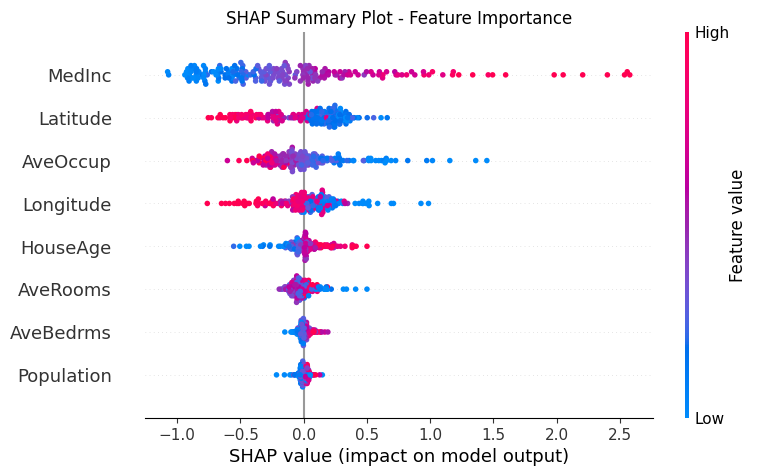

In [13]:
import matplotlib.pyplot as plt
# Assuming 'shap_values' and 'X_train' are already calculated
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=housing.feature_names,
    # plot_type="bar",
    show=False
)

import matplotlib.pyplot as plt
plt.title("SHAP Summary Plot - Feature Importance")
plt.show()


In [14]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8c7e5365abcadecd2933af121e9c7377dd7df81753b14f98f190cda47374d03e
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [15]:
from lime.lime_tabular import LimeTabularExplainer

In [16]:
explainer = LimeTabularExplainer(
    X_train,
    feature_names=housing.feature_names,
    mode='regression'
)

In [19]:
i = 0

exp = explainer.explain_instance(
    X_test[i],
    regressor.predict,
    num_features=8
)

In [20]:
exp.show_in_notebook()

In [21]:
print(exp.as_list())

[('Latitude <= 33.93', 0.6256449282998046), ('Longitude > -118.00', -0.5760590429952883), ('AveOccup > 3.28', -0.36387645580623934), ('3.55 < MedInc <= 4.75', -0.06573140874260729), ('18.00 < HouseAge <= 29.00', -0.020162258203693502), ('5.23 < AveRooms <= 6.06', -0.019026212584950682), ('1.05 < AveBedrms <= 1.10', -0.01708351108332722), ('1167.00 < Population <= 1724.00', 0.01367275897019543)]


Figure(640x480)


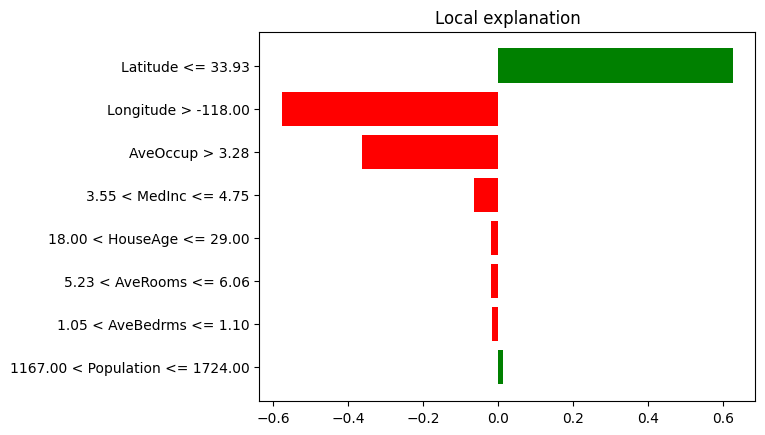

In [23]:
print(exp.as_pyplot_figure())